In [1]:
import pandas as pd
from sqlalchemy import create_engine

In [4]:
!pip install python-dotenv

  Using cached python_dotenv-1.0.1-py3-none-any.whl.metadata (23 kB)
Using cached python_dotenv-1.0.1-py3-none-any.whl (19 kB)


In [2]:
import os
from dotenv import load_dotenv

# Carrega as variáveis de ambiente do arquivo .env
load_dotenv(dotenv_path="../.env_dev")

True

In [3]:
def create_conn():
    # Defina os parâmetros de conexão
    db_user = os.getenv('DB_USER')
    db_password = os.getenv('DB_PASSWORD')
    db_host = os.getenv('DB_HOST')
    db_port = '5432'
    db_name = 'magic-steps'

    # Crie a URL de conexão
    connection_url = f'postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}'

    # Crie um engine do SQLAlchemy
    engine = create_engine(connection_url)
    return engine
engine = create_conn()

In [5]:
# Query para listar todas as tabelas
query = """
SELECT *
FROM magic_steps.aluno_nota_completo limit 4500
"""

df = pd.read_sql_query(query, engine)
df.head()

,idaluno,idturma,motivoinativacao,nomedisciplina,notafase,nomefase,idfasenota,numerofase,idade,corraca,sexo,datasituacaoativo,datasituacaoinativo,datahoraefetivacaomatricula,diasmatriculado,inativo
0,3,210,None,INGLÊS,2.5,DIAGNOSTICA 1,266,1,19.0,R,F,2022-01-01 00:00:00,2022-12-31 00:00:00,2022-01-20 00:00:00,345.0,False
1,3,210,None,PORTUGUÊS,5.5,DIAGNOSTICA 1,266,1,19.0,R,F,2022-01-01 00:00:00,2022-12-31 00:00:00,2022-01-20 00:00:00,345.0,False
2,3,210,None,MATEMÁTICA,4.5,DIAGNOSTICA 1,266,1,19.0,R,F,2022-01-01 00:00:00,2022-12-31 00:00:00,2022-01-20 00:00:00,345.0,False
3,3,303,None,INGLÊS,2.5,DIAGNOSTICA 1,278,1,19.0,R,F,2022-01-01 00:00:00,2022-12-31 00:00:00,2022-02-28 00:00:00,306.0,False
4,3,303,None,INGLÊS,8.0,1º SEMESTRE,279,2,19.0,R,F,2022-01-01 00:00:00,2022-12-31 00:00:00,2022-02-28 00:00:00,306.0,False


In [10]:
# Extrair uma amostra de 10.000 registros
df_sample = df.sample(n=1000, random_state=42)

# Salvar a amostra em um novo arquivo CSV
df_sample.to_csv('./dados_amostra2.csv', index=False)

In [11]:
# Tentativa final de carregar e analisar o arquivo CSV
try:
    # Carregar o arquivo
    df = pd.read_csv('dados_amostra2.csv')

    # Exibir as primeiras linhas e as informações gerais do dataframe
    df_head = df.head()
    df_info = df.info()
    df_description = df.describe(include='all')

    df_head, df_info, df_description

except Exception as e:
    str(e)  # Retornar a mensagem de erro específica, se ocorrer



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   idaluno                      1000 non-null   int64  
 1   idturma                      1000 non-null   int64  
 2   motivoinativacao             46 non-null     object 
 3   nomedisciplina               1000 non-null   object 
 4   notafase                     1000 non-null   float64
 5   nomefase                     1000 non-null   object 
 6   idfasenota                   1000 non-null   int64  
 7   numerofase                   1000 non-null   int64  
 8   idade                        1000 non-null   float64
 9   corraca                      1000 non-null   object 
 10  sexo                         1000 non-null   object 
 11  datasituacaoativo            1000 non-null   object 
 12  datasituacaoinativo          1000 non-null   object 
 13  datahoraefetivacaom

In [13]:
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 26.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.1/41.1 MB 27.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 40.0 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.1.2 -> 24.2
[notice] To update, run: pip install --upgrade pip


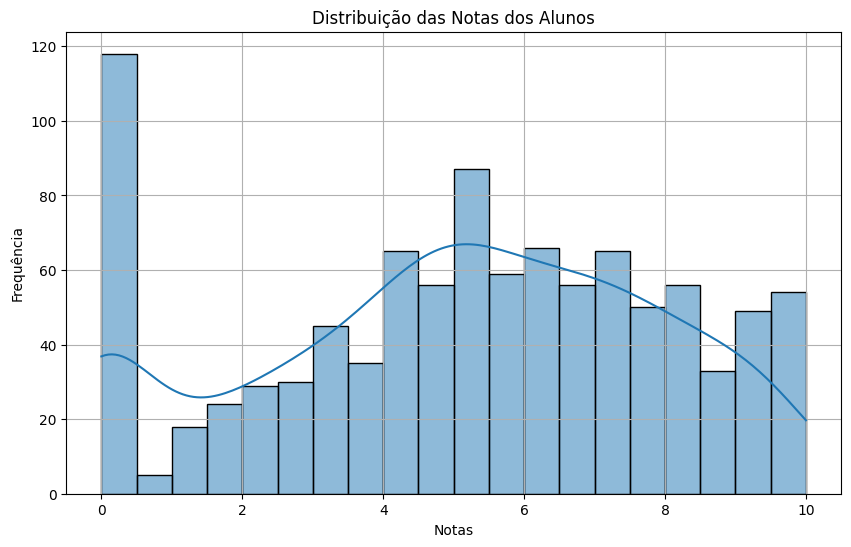

In [18]:

plt.figure(figsize=(10, 6))
sns.histplot(df['notafase'], bins=20, kde=True)
plt.title('Distribuição das Notas dos Alunos')
plt.xlabel('Notas')
plt.ylabel('Frequência')
plt.grid()
plt.show()

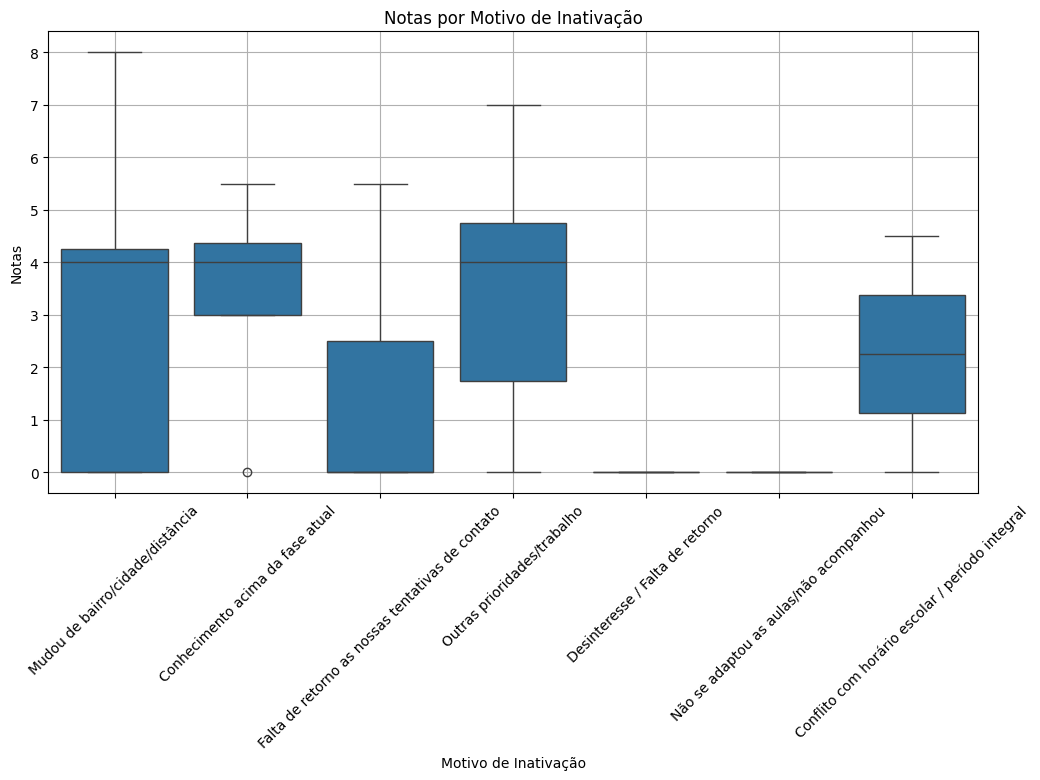

In [19]:
# Analisando a relação entre o motivo de inativação e as notas
plt.figure(figsize=(12, 6))
sns.boxplot(x='motivoinativacao', y='notafase', data=df)
plt.title('Notas por Motivo de Inativação')
plt.xlabel('Motivo de Inativação')
plt.ylabel('Notas')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Selecionar caracter\u00edsticas relevantes
features = ['idade', 'notafase', 'numerofase', 'diasmatriculado']

X = df[features]
y = df['inativo']

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizar os dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Criar e treinar o modelo
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Fazer previs\u00f5es
y_pred = model.predict(X_test_scaled)

# Avaliar o modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Acur\u00e1cia do modelo: {accuracy:.2f}")
print("\
Relat\u00f3rio de classifica\u00e7\u00e3o:")
print(classification_report(y_test, y_pred))

# Import\u00e2ncia das caracter\u00edsticas
feature_importance = pd.DataFrame({'feature': features, 'importance': abs(model.coef_[0])})
feature_importance = feature_importance.sort_values('importance', ascending=False)
print("\
Import\u00e2ncia das caracter\u00edsticas:")
print(feature_importance)

Acurácia do modelo: 0.99
Relatório de classificação:
              precision    recall  f1-score   support

       False       0.99      1.00      0.99       197
        True       1.00      0.33      0.50         3

    accuracy                           0.99       200
   macro avg       0.99      0.67      0.75       200
weighted avg       0.99      0.99      0.99       200

Importância das características:
           feature  importance
2       numerofase    2.220152
3  diasmatriculado    1.525899
0            idade    0.198825
1         notafase    0.022766


In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Selecionar caracter\u00edsticas relevantes
features = ['idade', 'notafase', 'numerofase', 'diasmatriculado']

# Embaralhar o DataFrame
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Separar os recursos e o alvo (supondo que a coluna alvo se chame 'target')
X = df_shuffled[features]
y = df_shuffled['inativo']

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizar os dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Criar e treinar o modelo
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Fazer previsão
y_pred = model.predict(X_test_scaled)

# Avaliar o modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Acuracia do modelo: {accuracy:.2f}")
print("\
Relatório de classificação:")
print(classification_report(y_test, y_pred))

# Importancia das caracteristicas
feature_importance = pd.DataFrame({'feature': features, 'importance': abs(model.coef_[0])})
feature_importance = feature_importance.sort_values('importance', ascending=False)
print("Importancia das caracteristicas:")
print(feature_importance)

Acurácia do modelo: 0.95
Relatório de classificação:
              precision    recall  f1-score   support

       False       0.97      0.98      0.98       191
        True       0.50      0.33      0.40         9

    accuracy                           0.95       200
   macro avg       0.73      0.66      0.69       200
weighted avg       0.95      0.95      0.95       200

Importância das características:
           feature  importance
2       numerofase    2.457220
3  diasmatriculado    1.829914
0            idade    0.461508
1         notafase    0.210024
